# Price spreads -- the quantity that actually drives the DFL gradient

Single-price's exact training gradient (derived and autograd-verified in
`9_analysis/single_price_gradient_mechanism.md`) is

```
d(f_dfl)/d(pl_hat_h) = dt * (pi_da_h - pi_imb_h)
```

so `(da - imb)` by hour is the direct, literal visualisation of what single-price DFL
training pushes against at every hour: **positive spread pushes the forecast DOWN**
(imbalance cheaper than day-ahead that hour), **negative spread pushes it UP**. Plotting
`da`/`imb` as overlaid absolute price levels (an earlier version of this notebook) hides
this almost entirely -- the spread is a small difference riding on a much larger shared
diurnal price cycle. This version plots the spread directly instead.

Dual-price's asymmetric analogues, `(da - imb_up)` (short-side pull, identical in sign to
single-price's) and `(da - imb_down)` (long-side pull, weaker post-fix -- see
`dual_price_gradient_mechanism.md` Section 3), are plotted alongside for comparison.

Two periods (training gradient is shaped by 2018 data; reported findings are measured on
the test year), and both real (settlement) and forecasted/proxy (`_fc`, decision-time)
prices -- the `_fc` versions are what the DECISION solve actually sees, never the real
columns, per the firewall documented throughout `6_models/`. A closing section checks each
spread's correlation with solar irradiance directly (not mediated through any forecaster
behaviour, unlike the earlier bias-vs-solar checks in `8_testing/forecast_characteristics.ipynb`).

In [1]:
from __future__ import annotations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyprojroot import here

ROOT_DIR = here()
DATA_DIR = ROOT_DIR / "1_data" / "processed"

TRAIN_START = pd.Timestamp("2018-01-01 00:00:00+00:00")
TRAIN_END = pd.Timestamp("2018-12-31 23:00:00+00:00")
TEST_START = pd.Timestamp("2019-07-01 00:00:00+00:00")
TEST_END = pd.Timestamp("2020-06-30 23:00:00+00:00")

PRICE_COLS = ["da", "imb", "imb_up", "imb_down", "da_fc", "imb_fc", "imb_up_fc", "imb_down_fc"]
ALL_COLS = PRICE_COLS + ["solar_irrad"]

df_full = pd.read_csv(DATA_DIR / "df_full.csv", parse_dates=["datetime"]).set_index("datetime")
missing = [c for c in ALL_COLS if c not in df_full.columns]
if missing:
    raise KeyError(f"missing columns: {missing}")
print(f"full range loaded: {df_full.index.min()} .. {df_full.index.max()}  ({len(df_full)} hours)")

PERIODS = {
    "training year (2018)": (TRAIN_START, TRAIN_END),
    "test year (2019-07..2020-06)": (TEST_START, TEST_END),
}
for label, (start, end) in PERIODS.items():
    n = len(df_full.loc[start:end])
    print(f"  {label}: {n} hours ({n/24:.0f} days)")

SPREADS = {
    "da - imb (single-price)": ("da", "imb"),
    "da - imb_up (dual, short side)": ("da", "imb_up"),
    "da - imb_down (dual, long side)": ("da", "imb_down"),
}
SPREADS_FC = {
    "da_fc - imb_fc (single-price)": ("da_fc", "imb_fc"),
    "da_fc - imb_up_fc (dual, short side)": ("da_fc", "imb_up_fc"),
    "da_fc - imb_down_fc (dual, long side)": ("da_fc", "imb_down_fc"),
}

full range loaded: 2017-11-03 00:00:00+00:00 .. 2020-07-09 23:00:00+00:00  (23520 hours)
  training year (2018): 8760 hours (365 days)
  test year (2019-07..2020-06): 8784 hours (366 days)


## Seasonal-hourly averaging + plotting helpers

Same season definitions as `forecast_characteristics.ipynb` (meteorological, pooled
across whichever period is selected regardless of calendar year). `E[da]-E[imb] ==
E[da-imb]` exactly (linearity of expectation), so spreads can be computed directly from
already-averaged price columns without approximation.

In [2]:
SEASON_MONTHS = {"spring": [3, 4, 5], "summer": [6, 7, 8], "autumn": [9, 10, 11], "winter": [12, 1, 2]}
SEASON_ORDER = ["spring", "summer", "autumn", "winter"]


def seasonal_hourly_avg(start, end):
    work = df_full.loc[start:end, ALL_COLS].copy()
    work["season"] = work.index.month.map({m: s for s, months in SEASON_MONTHS.items() for m in months})
    work["hour"] = work.index.hour
    seasonal_hourly = work.groupby(["season", "hour"])[ALL_COLS].mean()
    n_days = {s: int((work["season"] == s).sum() / 24) for s in SEASON_ORDER}
    return seasonal_hourly, n_days


def plot_spread_grid(seasonal_hourly, n_days, spread_specs, suptitle, ylabel="price spread (GBP/MWh)"):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
    handles = labels_ = None
    for ax, season in zip(axes.flat, SEASON_ORDER):
        for label, (col_a, col_b) in spread_specs.items():
            spread = (seasonal_hourly.loc[season, col_a] - seasonal_hourly.loc[season, col_b]).to_numpy()
            ax.plot(np.arange(24), spread, "-o", markersize=3, label=label, linewidth=1.6)
        ax.axhline(0, color="black", linewidth=0.9)
        ax.set_title(f"{season.capitalize()} (n={n_days[season]} days)", fontsize=10)
        ax.set_xlabel("hour")
        ax.set_ylabel(ylabel)
        if handles is None:
            handles, labels_ = ax.get_legend_handles_labels()

    fig.suptitle(suptitle, fontsize=13)
    fig.legend(handles, labels_, loc="lower center", ncol=len(labels_), fontsize=9, bbox_to_anchor=(0.5, -0.02))
    fig.tight_layout(rect=[0, 0.04, 1, 0.96])
    plt.show()

# Training year (2018)

In [3]:
sh_train, sh_train_ndays = seasonal_hourly_avg(TRAIN_START, TRAIN_END)
print('days per season:', sh_train_ndays)

days per season: {'spring': 92, 'summer': 92, 'autumn': 91, 'winter': 90}


## True price spreads, training year (2018)

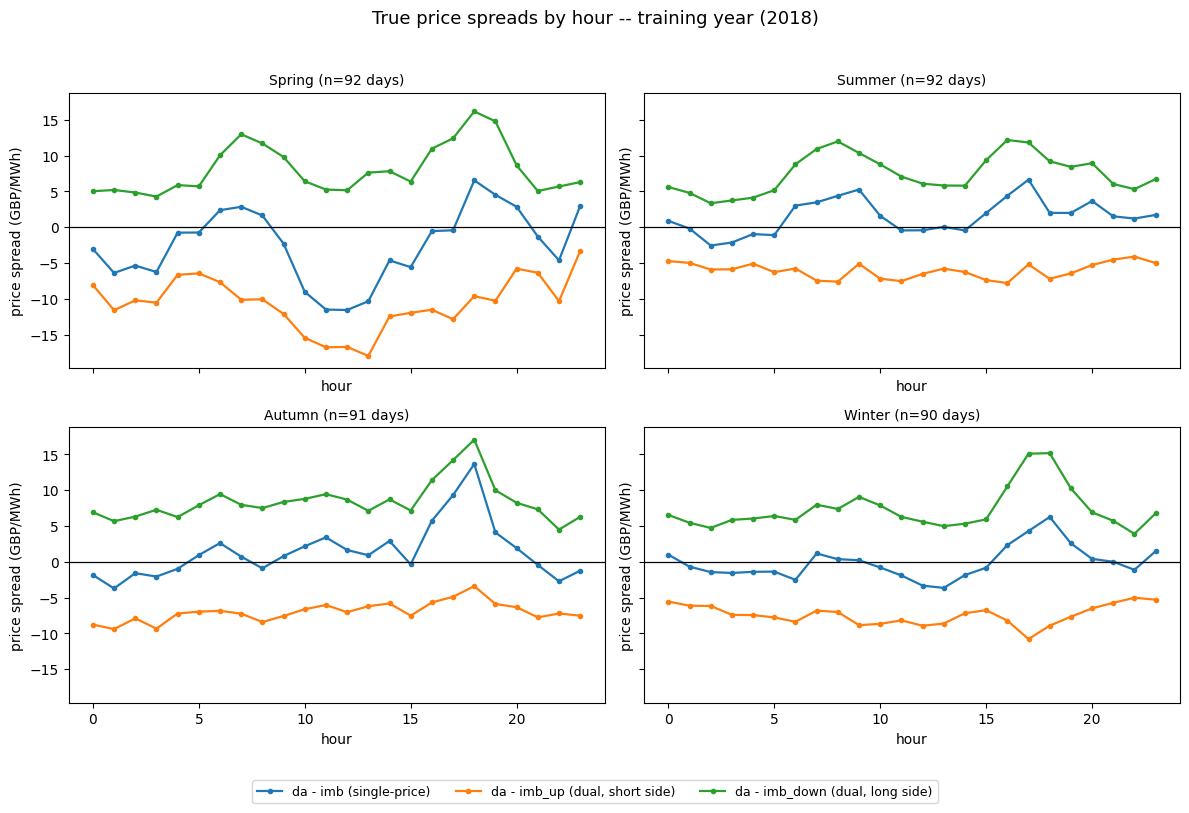

In [4]:
plot_spread_grid(sh_train, sh_train_ndays, SPREADS,
                 suptitle="True price spreads by hour -- training year (2018)")

## Forecasted/proxy price spreads, training year (2018)

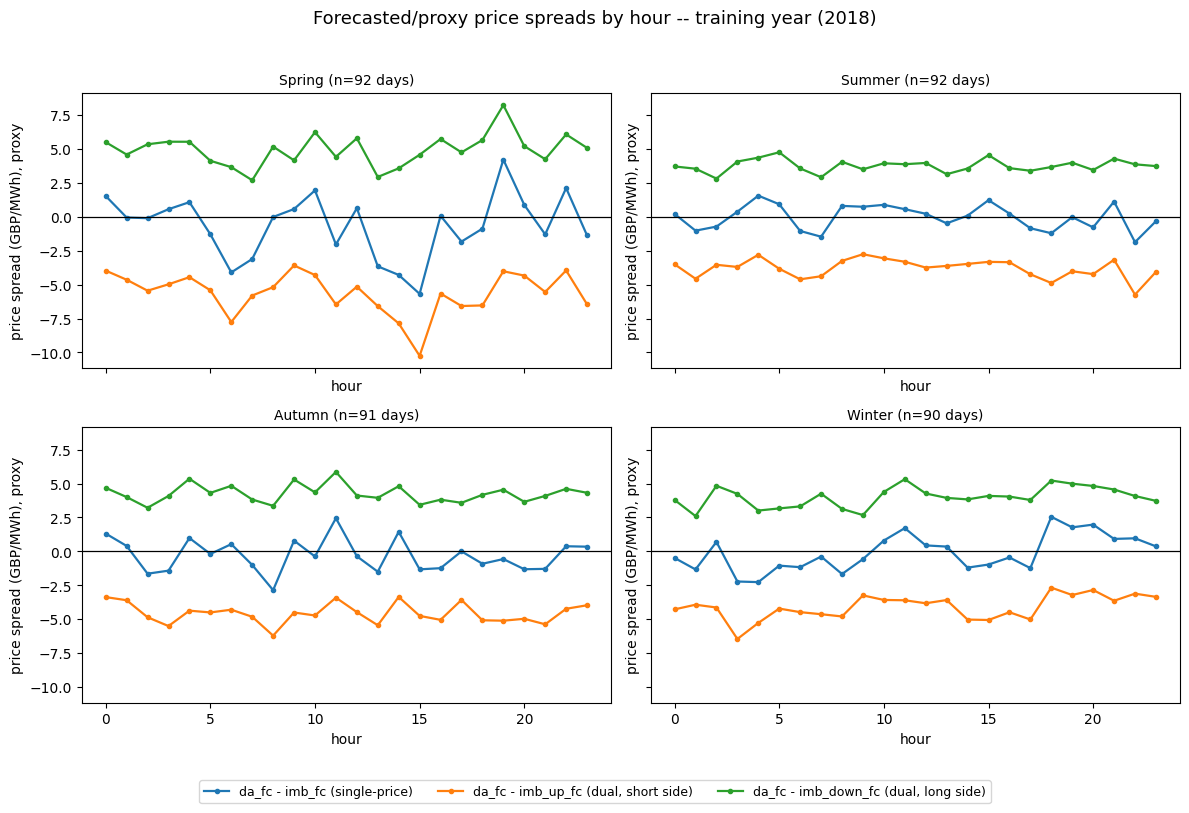

In [5]:
plot_spread_grid(sh_train, sh_train_ndays, SPREADS_FC,
                 suptitle="Forecasted/proxy price spreads by hour -- training year (2018)",
                 ylabel="price spread (GBP/MWh), proxy")

# Test year (2019-07..2020-06)

In [6]:
sh_test, sh_test_ndays = seasonal_hourly_avg(TEST_START, TEST_END)
print('days per season:', sh_test_ndays)

days per season: {'spring': 92, 'summer': 92, 'autumn': 91, 'winter': 91}


## True price spreads, test year (2019-07..2020-06)

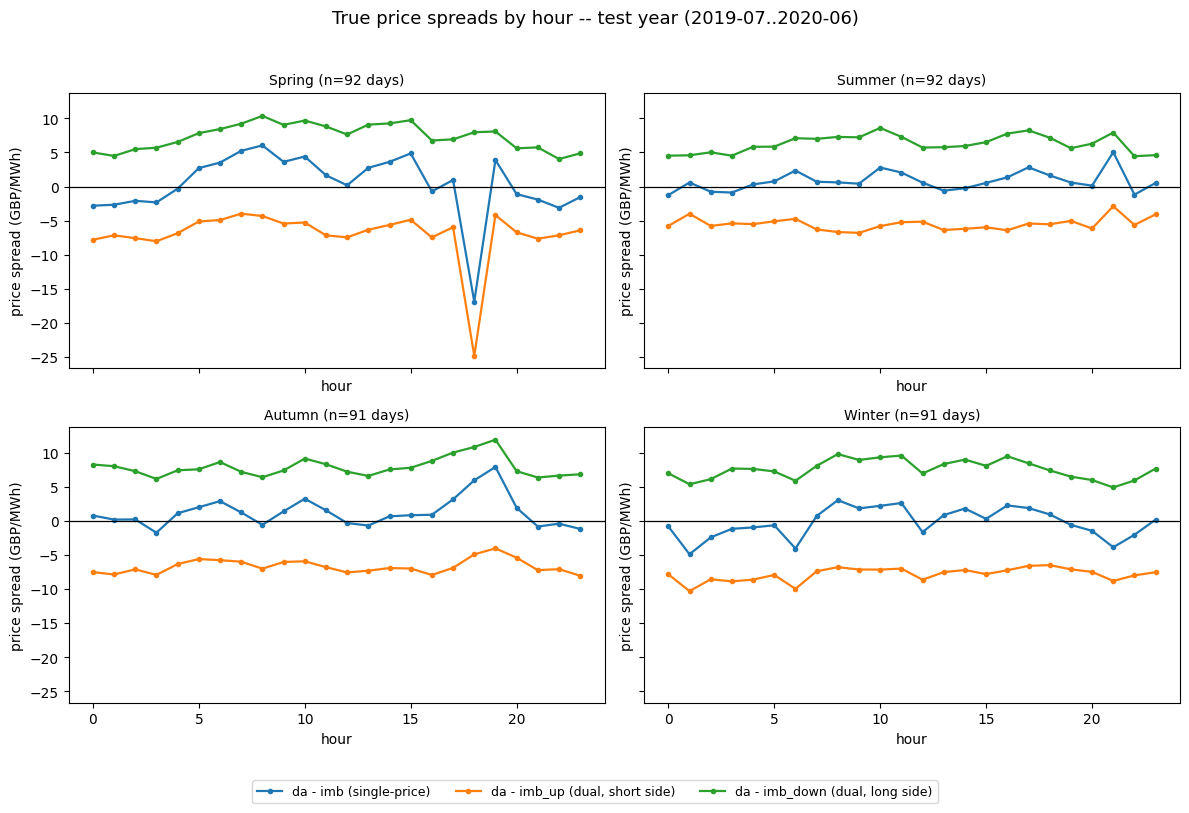

In [7]:
plot_spread_grid(sh_test, sh_test_ndays, SPREADS,
                 suptitle="True price spreads by hour -- test year (2019-07..2020-06)")

## Forecasted/proxy price spreads, test year (2019-07..2020-06)

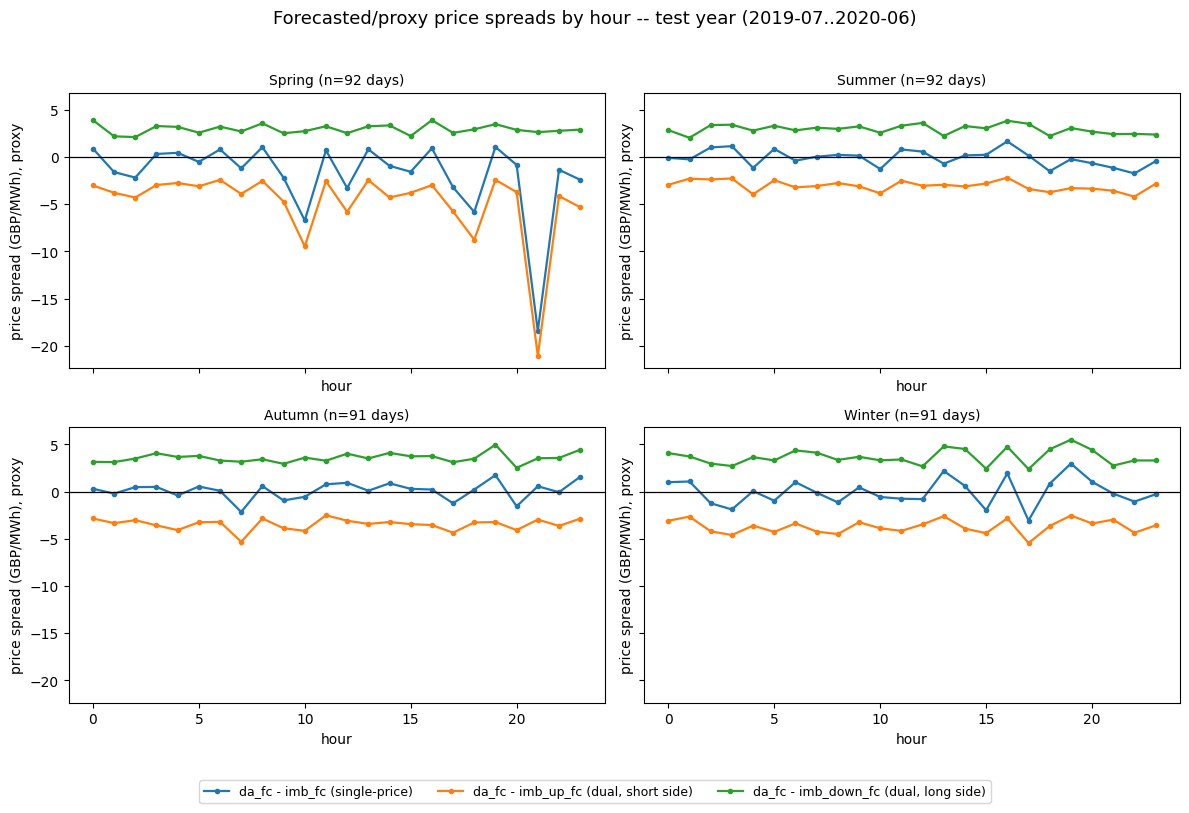

In [8]:
plot_spread_grid(sh_test, sh_test_ndays, SPREADS_FC,
                 suptitle="Forecasted/proxy price spreads by hour -- test year (2019-07..2020-06)",
                 ylabel="price spread (GBP/MWh), proxy")

# Correlation with solar irradiance

Two levels, since they can tell different stories (established earlier in this project's
bias-vs-solar checks): **hour-of-day** (pool every day in the period, average both the
spread and solar irradiance to one value per hour-of-day, then correlate across the 24
points -- the systematic diurnal relationship) and **pointwise** (correlate every
individual hourly observation directly, no averaging -- the day-to-day/instance-level
relationship). Unlike the earlier forecaster-bias-vs-solar checks, this is a direct
data-only relationship (no model in between), so both levels are informative here rather
than the pointwise level being structurally near-zero by construction.

In [9]:
def spread_solar_correlations(start, end, spreads):
    cols = list(dict.fromkeys(["solar_irrad"] + [c for pair in spreads.values() for c in pair]))
    raw = df_full.loc[start:end, cols].copy()
    raw["hour"] = raw.index.hour
    hourly_avg = raw.groupby("hour").mean()

    rows = []
    for label, (col_a, col_b) in spreads.items():
        spread_raw = raw[col_a] - raw[col_b]
        r_pointwise = np.corrcoef(raw["solar_irrad"], spread_raw)[0, 1]

        spread_hourly = hourly_avg[col_a] - hourly_avg[col_b]
        r_hourly = np.corrcoef(hourly_avg["solar_irrad"], spread_hourly)[0, 1]

        rows.append({"spread": label, "r_pointwise": r_pointwise, "R2_pointwise": r_pointwise ** 2,
                     "r_hour_of_day": r_hourly, "R2_hour_of_day": r_hourly ** 2})
    return pd.DataFrame(rows).set_index("spread")


pd.set_option("display.width", 160)
for period_label, (start, end) in PERIODS.items():
    print(f"=== {period_label} -- TRUE prices ===")
    display(spread_solar_correlations(start, end, SPREADS).round(4))
    print(f"=== {period_label} -- FORECASTED/PROXY prices ===")
    display(spread_solar_correlations(start, end, SPREADS_FC).round(4))
    print()

=== training year (2018) -- TRUE prices ===


,r_pointwise,R2_pointwise,r_hour_of_day,R2_hour_of_day
spread,,,,
da - imb (single-price),0.0464,0.0022,-0.2956,0.0874
"da - imb_up (dual, short side)",0.0298,0.0009,-0.8221,0.6758
"da - imb_down (dual, long side)",0.0508,0.0026,0.0700,0.0049


=== training year (2018) -- FORECASTED/PROXY prices ===


,r_pointwise,R2_pointwise,r_hour_of_day,R2_hour_of_day
spread,,,,
da_fc - imb_fc (single-price),0.0022,0.0000,-0.0818,0.0067
"da_fc - imb_up_fc (dual, short side)",0.0187,0.0004,-0.0394,0.0016
"da_fc - imb_down_fc (dual, long side)",-0.0220,0.0005,-0.0986,0.0097



=== test year (2019-07..2020-06) -- TRUE prices ===


,r_pointwise,R2_pointwise,r_hour_of_day,R2_hour_of_day
spread,,,,
da - imb (single-price),0.0414,0.0017,0.5189,0.2692
"da - imb_up (dual, short side)",0.0233,0.0005,0.1480,0.0219
"da - imb_down (dual, long side)",0.0534,0.0029,0.6149,0.3781


=== test year (2019-07..2020-06) -- FORECASTED/PROXY prices ===


,r_pointwise,R2_pointwise,r_hour_of_day,R2_hour_of_day
spread,,,,
da_fc - imb_fc (single-price),0.0101,0.0001,0.0960,0.0092
"da_fc - imb_up_fc (dual, short side)",0.0155,0.0002,0.0881,0.0078
"da_fc - imb_down_fc (dual, long side)",-0.0175,0.0003,0.0791,0.0063
